## 9b - Run Deprivation Model with AlphaEarth Satellite Embeddings

This script:
- Reads the per-buurt AlphaEarth embeddings produced by script 9a — **three variants**:
  - **whole-buurt zonal** (every 10 m pixel in the buurt; the original approach)
  - **road, single pixel** (the pixel under each panorama point; a weak sanity baseline)
  - **road, 20 m buffer** (pixels within 20 m of each panorama point; matches the street-view gaze)
- Selects which aggregation to use (mean, median, min, or max — all pre-computed in 9a)
- Joins each with the CBS SES-WOA deprivation target
- Fits and evaluates a regression model (XGBoost) for **each variant** using identical
  cross-validation, hyperparameter grid and split (raw-score R²)
- Compares all variants side by side against the street-view (CLIP) baseline from script 4

This mirrors the methodology of **script 4** so the comparison is like-for-like: the road
variants re-aggregate the *same* satellite raster over the *same* sampling support the
street-view model uses, isolating the effect of **sampling** from that of the **sensor**.
If the road-following variants close much of the gap to street view, AlphaEarth's weaker
fit was substantially a sampling artefact rather than a limitation of the embeddings.

### Dependencies
**Prerequisites:** Scripts 4 (best model for comparison) and 9a (AlphaEarth embeddings, all variants).

**Inputs:**
- `data/processed/per_buurt_embedding_summaries/alphaearth_embeddings.pkl` — whole-buurt zonal (script 9a)
- `data/processed/per_buurt_embedding_summaries/alphaearth_embeddings_road_point.pkl` — road, single pixel (script 9a)
- `data/processed/per_buurt_embedding_summaries/alphaearth_embeddings_road_buffer.pkl` — road, 20 m buffer (script 9a)
- `data/models/best_model.joblib` — from script 4 (for comparison only)
- CBS SES-WOA target (via `amsterdam_data.get_ses_woa()`)
- Amsterdam buurt boundaries (via `amsterdam_data.get_amsterdam_buurten()`) — for residuals map
- `clustering_functions.py` — imports `RANDOM_STATE`, `embedding_statistic`

**Outputs:**
- `data/models/best_model_alphaearth.joblib` — best XGBoost pipeline for the whole-buurt zonal variant
- `data/models/best_model_alphaearth_road_point.joblib` — best pipeline for the road single-pixel variant
- `data/models/best_model_alphaearth_road_buffer.joblib` — best pipeline for the road 20 m buffer variant
- `outputs/9b-alphaearth_variants_test_scatter.png` — test-set scatter for each variant

**Used by:** None (terminal analysis notebook)

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*glibc.*")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing
import joblib
import geopandas as gpd


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from xgboost import XGBRegressor

from model_evaluation import compute_metrics


def evaluate_model(y_true, y_pred, column, num_in_class=None, num_areas=None,
                   plot=True, plot_collectively=False, ax=None):
    """Compute regression metrics (via compute_metrics) and optionally plot true vs predicted."""
    metrics = compute_metrics(y_true, y_pred)

    if plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_true, y_pred, alpha=0.7)
        plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
        plt.xlabel(f"True {column}")
        plt.ylabel(f"Predicted {column}")
        plt.title(f"{column}")
        plt.grid(True)
        plt.show()

    if plot_collectively and ax is not None:
        ax.scatter(y_true, y_pred, alpha=0.7)
        ax.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{column}: \n{num_in_class} images\n {num_areas} buurten", fontsize=15)
        ax.grid(True)
        ax.text(
            0.01, 0.99,
            f'R² = {metrics["R2"]:.2f}, RMSE = {metrics["RMSE"]:.2f}',
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment='top',
            horizontalalignment='left')

    return metrics

In [2]:
from directory_filepaths import *
from clustering_functions import RANDOM_STATE, embedding_statistic
from amsterdam_data import get_ses_woa, get_amsterdam_buurten

In [3]:
# --- Configuration ---

var_to_predict = TARGET_COL  # 'ses_woa_score' (continuous; PRIMARY)

# Which aggregation of the per-buurt AlphaEarth embeddings to use as features.
# Script 9a pre-computes all of these for every variant: 'mean', 'median', 'min', 'max'.
# We use the centrally-defined statistic from clustering_functions.py for consistency.
AGGREGATION = embedding_statistic
embedding_col = f'{AGGREGATION}_embedding'

# The AlphaEarth feature variants to compare (label -> pickle from script 9a). All share
# the same per-buurt schema, so each is loaded and modelled identically. The road_* variants
# re-aggregate the SAME raster over the street-view sampling support (panorama points):
#   whole-buurt zonal : every 10 m pixel in the buurt (the original approach)
#   road, single pixel: the single pixel under each panorama point (weak sanity baseline)
#   road, 20m buffer  : median of pixels within 20 m of each panorama point (matches the SVI gaze)
EMBEDDING_SOURCES = {
    'AlphaEarth — whole-buurt zonal':  'alphaearth_embeddings.pkl',
    'AlphaEarth — road, single pixel': 'alphaearth_embeddings_road_point.pkl',
    'AlphaEarth — road, 20m buffer':   'alphaearth_embeddings_road_buffer.pkl',
}

print(f"Predicting '{var_to_predict}' using '{embedding_col}' features (from clustering_functions.py)")
print("Variants to compare:")
for lab, pkl in EMBEDDING_SOURCES.items():
    print(f"  {lab:34s} <- {pkl}")

Predicting 'ses_woa_score' using 'median_embedding' features (from clustering_functions.py)
Variants to compare:
  AlphaEarth — whole-buurt zonal     <- alphaearth_embeddings.pkl
  AlphaEarth — road, single pixel    <- alphaearth_embeddings_road_point.pkl
  AlphaEarth — road, 20m buffer      <- alphaearth_embeddings_road_buffer.pkl


### Get SES-WOA data

In [4]:
ses = get_ses_woa()  # buurtcode, ses_woa_score, ses_welvaart, ses_opleiding, ses_arbeidsverleden
ses

,buurtcode,ses_woa_score,ses_welvaart,ses_opleiding,ses_arbeidsverleden
0,BU00340101,-0.400,-0.241,-0.061,-0.099
1,BU00340102,-0.145,-0.031,-0.038,-0.076
2,BU00340201,-0.072,-0.052,-0.027,0.007
3,BU00340202,0.230,0.116,0.056,0.058
4,BU00340203,-0.371,-0.198,-0.089,-0.084
...,...,...,...,...,...
641,BU03840501,-0.521,-0.325,0.125,-0.322
642,BU03840502,0.428,0.120,0.195,0.113
643,BU03840503,-0.901,-0.558,-0.030,-0.313
644,BU03840701,0.822,0.328,0.275,0.219


### Sanity check: map SES-WOA score

Quick choropleth to verify the deprivation data looks sensible (lower scores = more deprived).

In [ ]:
buurten = get_amsterdam_buurten()  # EPSG:28992
buurten_ses = buurten.merge(ses, on=JOIN_KEY, how='left')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
buurten_ses.plot(
    column='ses_woa_score',
    cmap='RdYlGn',  # red = low score (more deprived), green = high score (less deprived)
    legend=True,
    legend_kwds={'label': 'SES-WOA score (lower = more deprived)', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey'},
    ax=ax)
ax.set_title('CBS SES-WOA score by buurt - Amsterdam')
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Check the AlphaEarth embedding variants

Confirm which variant pickles script 9a produced and how many buurten each covers (after
joining to the SES-WOA target). Each is modelled separately below.

In [6]:
# Show which variant pickles (from script 9a) are present and their coverage.
# Each variant has the same schema: one row per buurt, with mean/median/min/max_embedding columns.
summary_dir = os.path.join(data_dir, "per_buurt_embedding_summaries")

for label, pkl in EMBEDDING_SOURCES.items():
    path = os.path.join(summary_dir, pkl)
    if os.path.exists(path):
        df = pd.read_pickle(path)
        merged = pd.merge(df, ses[[JOIN_KEY, var_to_predict]], on=JOIN_KEY)
        dim = len(merged.iloc[0][embedding_col]) if len(merged) else 'n/a'
        aggs = [c for c in df.columns if c.endswith('_embedding')]
        print(f"{label:34s}: {len(df):4d} buurten ({len(merged)} with SES), dim={dim}, aggs={aggs}")
    else:
        print(f"{label:34s}: MISSING — run script 9a  ({path})")

AlphaEarth — whole-buurt zonal    :  839 buurten (646 with SES), dim=64, aggs=['mean_embedding', 'median_embedding', 'min_embedding', 'max_embedding']
AlphaEarth — road, single pixel   :  641 buurten (641 with SES), dim=64, aggs=['mean_embedding', 'median_embedding', 'min_embedding', 'max_embedding']
AlphaEarth — road, 20m buffer     :  641 buurten (641 with SES), dim=64, aggs=['mean_embedding', 'median_embedding', 'min_embedding', 'max_embedding']


### Per-variant fit + evaluate function

One function loads a variant, splits 80/20, runs the same grid-searched cross-validation as
script 4, and evaluates on the held-out test set. The split, grid, CV folds and seed
(`RANDOM_STATE`) are identical across variants and to script 4, so every number is directly
comparable.

In [7]:
from sklearn.base import clone

# Same hyperparameter grid, CV and seed as script 4, applied identically to every variant
# so the numbers are directly comparable (to each other and to the street-view model).
PARAM_GRID = {
    'reg__n_estimators': [100, 300],         # number of boosting rounds (more = more complex)
    'reg__max_depth': [3, 6, 10],            # max tree depth (controls model complexity)
    'reg__learning_rate': [0.01, 0.1, 0.3],  # step size shrinkage (lower = slower but often better)
    'reg__subsample': [0.8, 1.0],            # fraction of training rows per tree (< 1 adds regularisation)
}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
ncores = min(multiprocessing.cpu_count() - 1, 100)


def fit_and_evaluate_source(label, pkl):
    """Load one per-buurt embedding variant, fit the XGBoost+CV pipeline (identical to
    script 4) and evaluate on a held-out 20% test set.

    Returns a results dict, or None if the variant's pickle is missing. The split, grid,
    CV folds and seed match across variants and script 4, so CV R², CV NRMSE and test R²
    are directly comparable.
    """
    path = os.path.join(data_dir, "per_buurt_embedding_summaries", pkl)
    if not os.path.exists(path):
        print(f"[{label}] {path} not found — skipping (run script 9a).")
        return None

    df = pd.merge(pd.read_pickle(path), ses[[JOIN_KEY, var_to_predict]], on=JOIN_KEY)
    X = np.stack(df[embedding_col].values)
    y = df[var_to_predict].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('reg', XGBRegressor(objective='reg:squarederror', random_state=RANDOM_STATE,
                             n_jobs=-1, verbosity=0))])
    grid = GridSearchCV(pipeline, PARAM_GRID, cv=cv, scoring='r2', n_jobs=ncores, verbose=0)
    grid.fit(X_train, y_train)
    best = grid.best_estimator_

    # CV NRMSE for the best estimator (RMSE / std(y) per fold, then averaged — as scripts 7/8).
    nrmse_scores = []
    for tr_ix, va_ix in cv.split(X_train):
        m = clone(best)
        m.fit(X_train[tr_ix], y_train[tr_ix])
        p = m.predict(X_train[va_ix])
        nrmse_scores.append(np.sqrt(mean_squared_error(y_train[va_ix], p)) / np.std(y_train[va_ix]))
    cv_nrmse = float(np.mean(nrmse_scores))

    y_pred_test = best.predict(X_test)
    test_metrics = compute_metrics(y_test, y_pred_test)
    print(f"[{label}] {len(df):4d} buurten | CV R²={grid.best_score_:.3f} "
          f"NRMSE={cv_nrmse:.3f} | test R²={test_metrics['R2']:.3f} | best={grid.best_params_}")

    return dict(label=label, pkl=pkl, n_buurten=len(df), model=best,
                cv_r2=float(grid.best_score_), cv_nrmse=cv_nrmse,
                best_params=grid.best_params_, test_metrics=test_metrics,
                X=X, y=y, df=df, y_test=y_test, y_pred_test=y_pred_test)

### Fit and evaluate every variant

Run the function above for each AlphaEarth variant. Each does a 180-fit grid search
(36 candidates × 5 folds), so this trains a few hundred models in total.

In [8]:
print(f"Training {len(EMBEDDING_SOURCES)} variant(s) using {ncores} cores "
      f"({2 * 3 * 3 * 2} candidates × {cv.n_splits} folds each)\n")

results = {}
for label, pkl in EMBEDDING_SOURCES.items():
    print(f"Training: {label} ...")
    r = fit_and_evaluate_source(label, pkl)
    if r is not None:
        results[label] = r
    print()

if not results:
    raise RuntimeError("No AlphaEarth variants found on disk — run script 9a first.")

Training 3 variant(s) using 11 cores (36 candidates × 5 folds each)

Training: AlphaEarth — whole-buurt zonal ...
[AlphaEarth — whole-buurt zonal]  646 buurten | CV R²=0.136 NRMSE=0.928 | test R²=0.215 | best={'reg__learning_rate': 0.01, 'reg__max_depth': 10, 'reg__n_estimators': 300, 'reg__subsample': 0.8}

Training: AlphaEarth — road, single pixel ...
[AlphaEarth — road, single pixel]  641 buurten | CV R²=0.147 NRMSE=0.923 | test R²=0.148 | best={'reg__learning_rate': 0.01, 'reg__max_depth': 10, 'reg__n_estimators': 300, 'reg__subsample': 0.8}

Training: AlphaEarth — road, 20m buffer ...
[AlphaEarth — road, 20m buffer]  641 buurten | CV R²=0.161 NRMSE=0.915 | test R²=0.203 | best={'reg__learning_rate': 0.01, 'reg__max_depth': 10, 'reg__n_estimators': 300, 'reg__subsample': 0.8}



In [9]:
# Save the best model for each variant.
# The whole-buurt zonal variant keeps the original filename for backward compatibility.
model_dir = os.path.join("../data/models")
os.makedirs(model_dir, exist_ok=True)

SAVE_NAMES = {
    'AlphaEarth — whole-buurt zonal':  'best_model_alphaearth.joblib',
    'AlphaEarth — road, single pixel': 'best_model_alphaearth_road_point.joblib',
    'AlphaEarth — road, 20m buffer':   'best_model_alphaearth_road_buffer.joblib',
}

for label, r in results.items():
    bundle = {
        "model": r['model'],
        "name": "XGBoost",
        "cv_score_r2": r['cv_r2'],
        "cv_nrmse": r['cv_nrmse'],
        "best_params": r['best_params'],
        "embedding_source": r['pkl'],
        "embedding_dim": r['X'].shape[1],
    }
    fname = SAVE_NAMES.get(label, f"best_model_{r['pkl'].replace('.pkl', '')}.joblib")
    out_path = os.path.join(model_dir, fname)
    joblib.dump(bundle, out_path)
    print(f"Saved {label:34s} -> {out_path}")

Saved AlphaEarth — whole-buurt zonal     -> ../data/models/best_model_alphaearth.joblib
Saved AlphaEarth — road, single pixel    -> ../data/models/best_model_alphaearth_road_point.joblib
Saved AlphaEarth — road, 20m buffer      -> ../data/models/best_model_alphaearth_road_buffer.joblib


## Out-of-sample performance per variant

True vs predicted SES-WOA on each variant's held-out 20% test set, side by side.

Saved test-set scatter to ../outputs/9b-alphaearth_variants_test_scatter.png


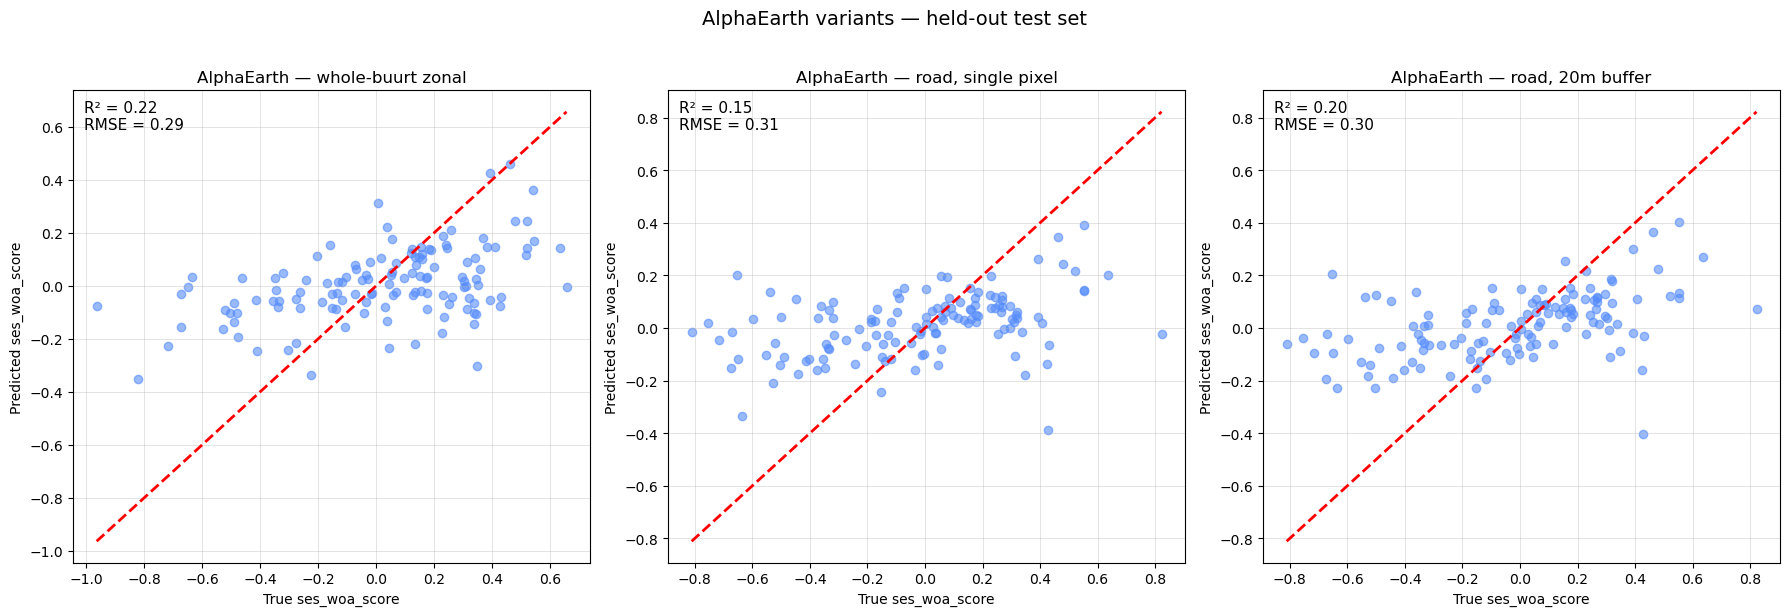


Test-set metrics per variant:

AlphaEarth — whole-buurt zonal:
  RMSE: 0.293
  NRMSE: 0.886
  MAE: 0.233
  R2: 0.215
  Spearman_rank_corr: 0.428

AlphaEarth — road, single pixel:
  RMSE: 0.312
  NRMSE: 0.923
  MAE: 0.238
  R2: 0.148
  Spearman_rank_corr: 0.424

AlphaEarth — road, 20m buffer:
  RMSE: 0.302
  NRMSE: 0.893
  MAE: 0.229
  R2: 0.203
  Spearman_rank_corr: 0.509


In [10]:
# Test-set true vs predicted for every variant, side by side.
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), squeeze=False)

for ax, (label, r) in zip(axes[0], results.items()):
    m = r['test_metrics']
    ax.scatter(r['y_test'], r['y_pred_test'], alpha=0.6)
    lo, hi = min(r['y_test']), max(r['y_test'])
    ax.plot([lo, hi], [lo, hi], 'r--', lw=2)
    ax.set_xlabel(f"True {var_to_predict}")
    ax.set_ylabel(f"Predicted {var_to_predict}")
    ax.set_title(label, fontsize=12)
    ax.text(0.02, 0.98, f"R² = {m['R2']:.2f}\nRMSE = {m['RMSE']:.2f}",
            transform=ax.transAxes, va='top', ha='left', fontsize=11)
    ax.grid(True)

fig.suptitle("AlphaEarth variants — held-out test set", fontsize=14, y=1.02)
plt.tight_layout()

output_path = os.path.join(outputs_dir, "9b-alphaearth_variants_test_scatter.png")
plt.savefig(output_path, bbox_inches="tight")
print(f"Saved test-set scatter to {output_path}")
plt.show()

print("\nTest-set metrics per variant:")
for label, r in results.items():
    print(f"\n{label}:")
    for k, v in r['test_metrics'].items():
        print(f"  {k}: {v:.3f}")

## Compare all variants with the street-view model

Load the street-view (CLIP) model from script 4 and tabulate it alongside every AlphaEarth
variant. The key question: does the **road, 20 m buffer** variant close the gap to street
view that the **whole-buurt zonal** approach leaves open?

In [11]:
# Full comparison incl. the street-view (CLIP) baseline from script 4.
sv_model_path = os.path.join("../data/models", "best_model.joblib")

print("=" * 86)
print(f"{'Feature source':40s} {'buurten':>7} {'CV R²':>7} {'CV NRMSE':>9} {'test R²':>8}")
print("-" * 86)

if os.path.exists(sv_model_path):
    sv_bundle = joblib.load(sv_model_path)
    sv_nrmse = sv_bundle.get('cv_nrmse', float('nan'))
    sv_nrmse_str = f"{sv_nrmse:9.3f}" if isinstance(sv_nrmse, float) else f"{sv_nrmse:>9}"
    print(f"{'Street View (CLIP, 512-d) [script 4]':40s} {'—':>7} "
          f"{sv_bundle['cv_score_r2']:7.3f} {sv_nrmse_str} {'—':>8}")
else:
    print(f"Street-view model not found at {sv_model_path} — run script 4 to include it.")

for label, r in results.items():
    print(f"{label:40s} {r['n_buurten']:7d} {r['cv_r2']:7.3f} {r['cv_nrmse']:9.3f} "
          f"{r['test_metrics']['R2']:8.3f}")
print("=" * 86)

print("\nInterpretation:")
print("- If 'road, 20m buffer' lifts R² well above 'whole-buurt zonal' (and above the bare")
print("  'road, single pixel' baseline), AlphaEarth's deficit was substantially a SAMPLING")
print("  artefact — aggregating over non-residential land cover diluted the signal.")
print("- If all three AlphaEarth variants stay close together and well below street view,")
print("  the gap is more likely intrinsic to the overhead view (the sensor), not sampling.")

Feature source                           buurten   CV R²  CV NRMSE  test R²
--------------------------------------------------------------------------------------
Street View (CLIP, 512-d) [script 4]           —   0.468     0.727        —
AlphaEarth — whole-buurt zonal               646   0.136     0.928    0.215
AlphaEarth — road, single pixel              641   0.147     0.923    0.148
AlphaEarth — road, 20m buffer                641   0.161     0.915    0.203

Interpretation:
- If 'road, 20m buffer' lifts R² well above 'whole-buurt zonal' (and above the bare
  'road, single pixel' baseline), AlphaEarth's deficit was substantially a SAMPLING
  artefact — aggregating over non-residential land cover diluted the signal.
- If all three AlphaEarth variants stay close together and well below street view,
  the gap is more likely intrinsic to the overhead view (the sensor), not sampling.


Map of the residuals (true − predicted) across Amsterdam buurten, for the headline
**road, 20 m buffer** variant (falls back to whichever variant is available).

In [ ]:
# Residual map for the headline road-following variant (fall back to whichever is available).
HEADLINE = 'AlphaEarth — road, 20m buffer'
r = results.get(HEADLINE) or next(iter(results.values()))
print(f"Residual map for: {r['label']}")

# Predict on ALL buurten (not just the test set) so we get a complete map
y_pred_all = r['model'].predict(r['X'])
residuals = r['y'] - y_pred_all  # positive = model under-predicted SES-WOA (true score higher)

# Attach residuals to the dataframe and merge with geometries
residual_df = r['df'][[JOIN_KEY]].copy()
residual_df['residual'] = residuals

buurten = get_amsterdam_buurten()
ams_residuals = buurten.merge(residual_df, on=JOIN_KEY, how='inner')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
vmax = np.percentile(np.abs(ams_residuals['residual']), 95)  # symmetric colour scale clipped at 95th percentile
ams_residuals.plot(
    column='residual',
    cmap='RdBu',       # red = negative residual (over-predicted SES-WOA score)
    vmin=-vmax,         # blue = positive residual (under-predicted SES-WOA score)
    vmax=vmax,
    legend=True,
    legend_kwds={'label': 'Residual (True − Predicted SES-WOA score)', 'shrink': 0.6},
    ax=ax)
ax.set_title(f"Model Residuals — {r['label']}")
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Mapped {len(ams_residuals)} buurten")
print(f"Mean residual: {residuals.mean():.3f}, Std: {residuals.std():.3f}")